# HW 7: More Logistic Regression

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import seaborn as sns
sns.set()

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from statsmodels.discrete.discrete_model import Logit
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor,
    OLSInfluence
)
from statsmodels.tools.tools import add_constant

In [2]:
%matplotlib inline
%load_ext pycodestyle_magic

In [3]:
def plot_cv_results(cv_results, param_x, param_z, metric='mean_test_score'):
    """
    cv_results - cv_results_ attribute of a GridSearchCV instance (or similar)
    param_x - name of grid search parameter to plot on x axis
    param_z - name of grid search parameter to plot by line color
    """
    cv_results = pd.DataFrame(cv_results)
    col_x = 'param_' + param_x
    col_z = 'param_' + param_z
    fig, ax = plt.subplots(1, 1, figsize=(11, 8))
    sns.pointplot(x=col_x, y=metric, hue=col_z, data=cv_results, ci=99, n_boot=64, ax=ax)
    plt.xticks(rotation=90)
    ax.set_title("CV Grid Search Results")
    ax.set_xlabel(param_x)
    ax.set_ylabel(metric)
    ax.legend(title=param_z)
    return fig

## Import data

In [4]:
df = pd.read_csv('data/churn_modelling_train.csv', index_col=0)

In [5]:
df.shape

(8000, 12)

In [6]:
df.head()

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CustomerId,,,,,,,,,,,,
15720050,Barrett,727,France,Female,28,2,110997.76,1,1,0,101433.76,0
15696301,Snider,719,France,Female,37,9,101455.70,1,1,0,25803.59,1
15643865,Lo Duca,601,France,Female,40,3,92055.36,1,0,1,164652.02,1
15677538,Nwokike,569,France,Male,38,7,0.00,1,1,1,108469.20,0
15740494,Cameron,633,France,Female,33,3,0.00,2,1,0,191111.02,0


From the description:
    
__CustomerId__
Unique Ids for bank customer identification

__Surname__
Customer's last name

__CreditScore__
Credit score of the customer

__Geography__
The country from which the customer belongs

__Gender__
Male or Female

__Age__
Age of the customer

__Tenure__
Number of years for which the customer has been with the bank

__Balance__
Bank balance of the customer

__NumOfProducts__
Number of bank products the customer is utilising

__HasCrCard__
Binary Flag for whether the customer holds a credit card with the bank or not

__IsActiveMember__
Binary Flag for whether the customer is an active member with the bank or not

__EstimatedSalary__
Estimated salary of the customer in Dollars

__Exited__
Binary flag 1 if the customer closed account with bank and 0 if the customer is retained (__Target__)

 

## EDA

In [7]:
df.isnull().sum()

Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

### Numerical features

In [9]:
plot_data = df.copy()

In [10]:
[c for c in plot_data.columns if (c != 'Exited') & 
 (plot_data[c].dtype != 'object')]

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary']

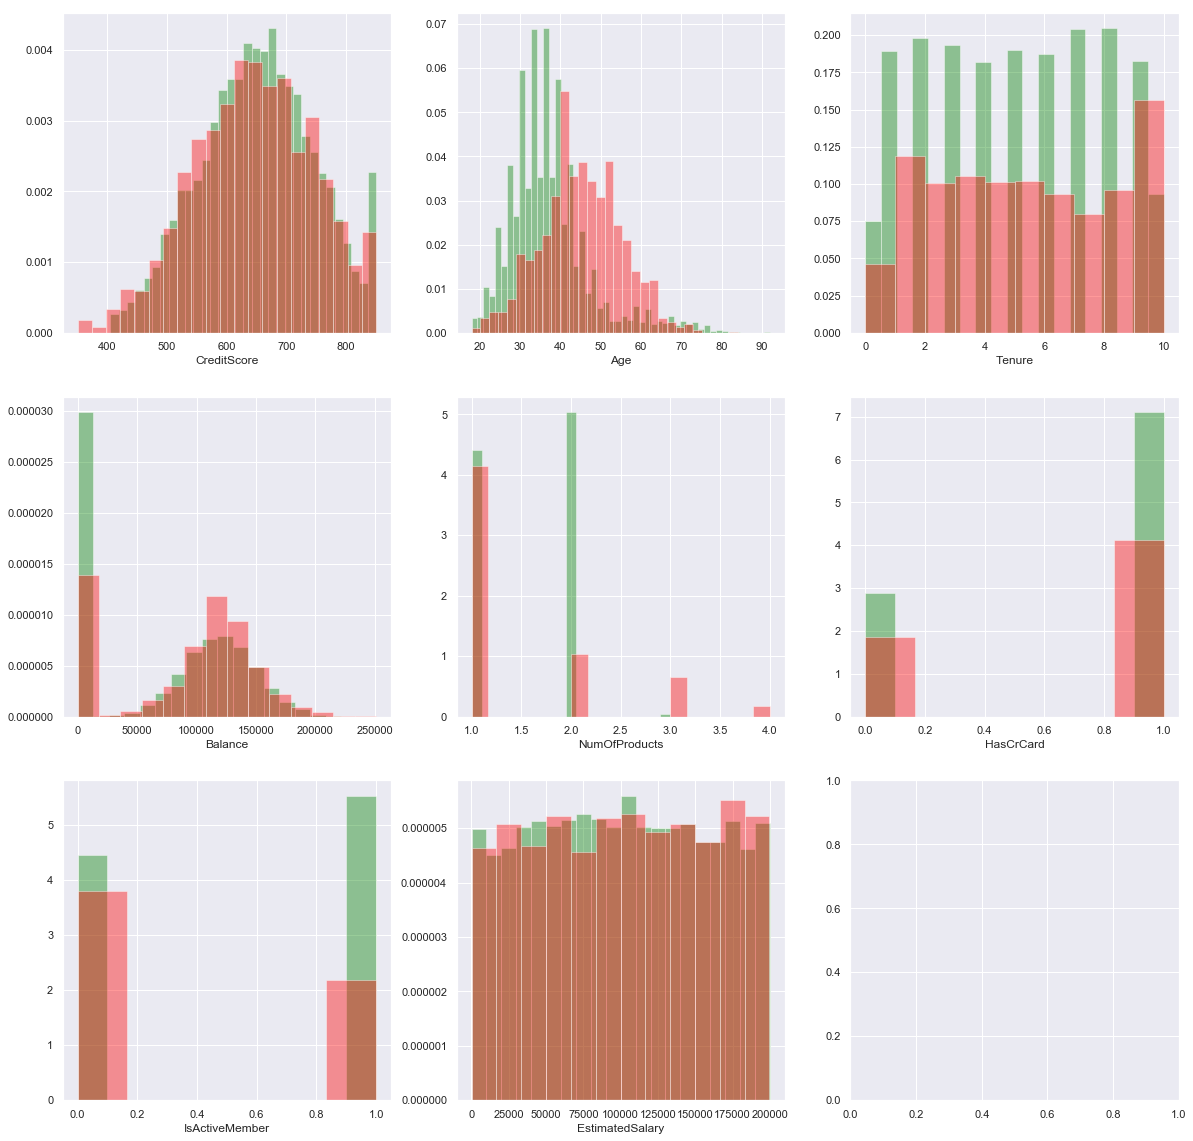

In [13]:
fig, axs = plt.subplots(3, 3, figsize=(20, 20))

feature_names = [c for c in plot_data.columns if (c != 'Exited') &
                 (plot_data[c].dtype != 'object')]

for name, ax in zip(feature_names, axs.flatten()):
    sns.distplot(plot_data.loc[plot_data['Exited'] == 0, name],
                 ax=ax, color='green', kde=False, norm_hist=True)
    sns.distplot(plot_data.loc[plot_data['Exited'] == 1, name],
                 ax=ax, color='red', kde=False, norm_hist=True)

### See what happens with the zero balance customers

Part of exited customers among the ones with __zero balance__

In [14]:
df.loc[df['Balance'] == 0, 'Exited'].sum()/\
    df.loc[df['Balance'] == 0,'Exited'].shape[0]

0.13949463482173763

Part of exited customers among __all of the surveyed ones__

In [15]:
df.loc[:, 'Exited'].sum()/df.loc[:, 'Exited'].shape[0]

0.20275

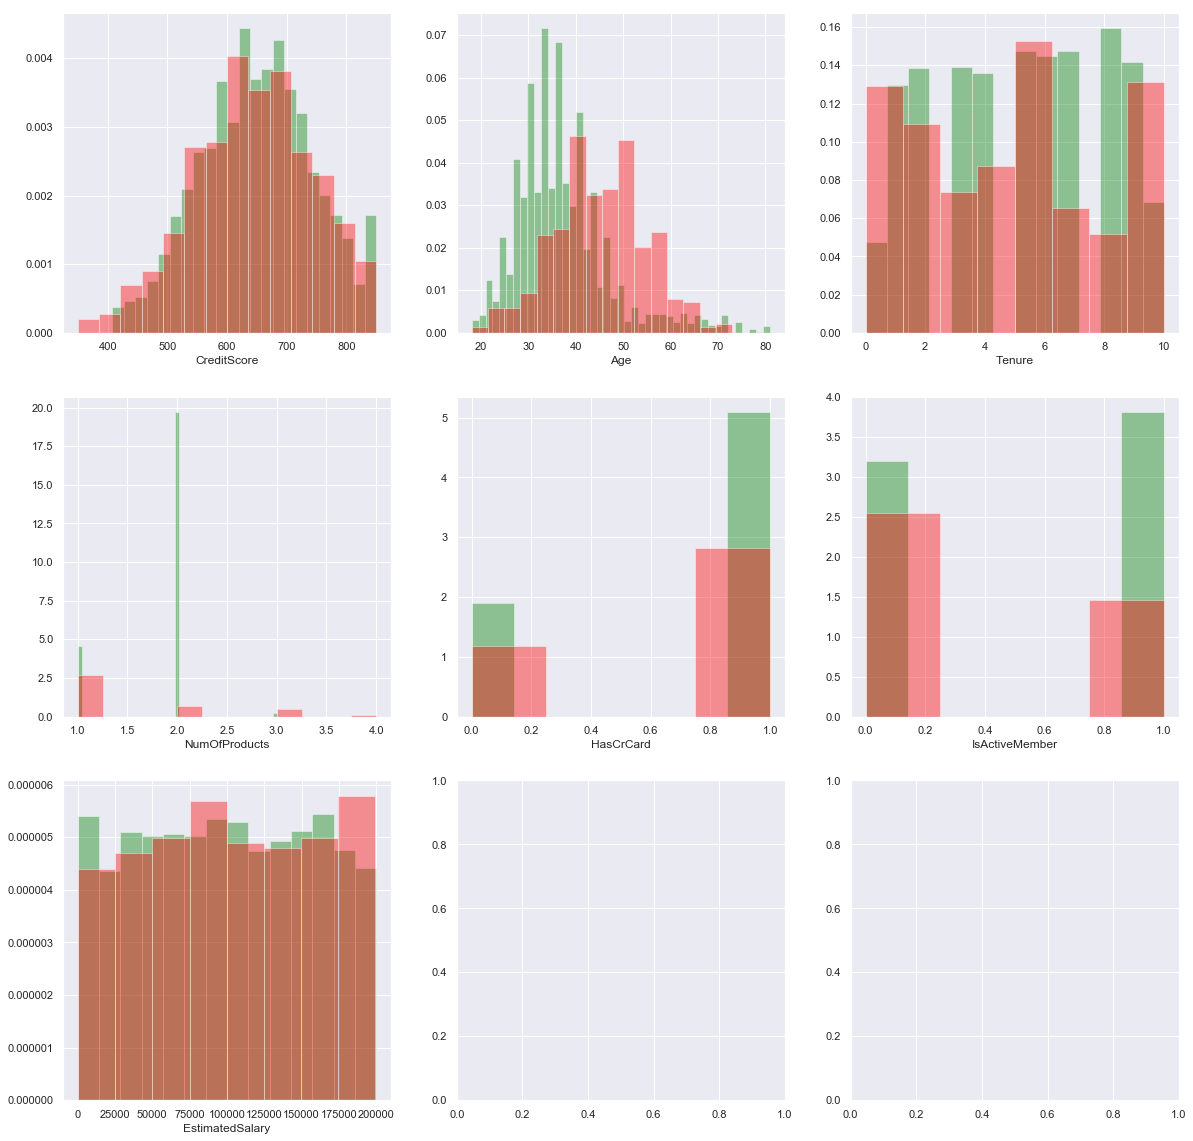

In [16]:
fig, axs = plt.subplots(3, 3, figsize=(20, 20))
plot_data=df.loc[df['Balance']==0, :]

feature_names = [c for c in plot_data.columns
                 if (c != 'Exited') &
                 (plot_data[c].dtype != 'object') &
                 (c != 'Balance')]

for name, ax in zip(feature_names, axs.flatten()):
    sns.distplot(plot_data.loc[plot_data['Exited'] == 0, name],
                 ax=ax, color='green', kde=False, norm_hist=True)
    sns.distplot(plot_data.loc[plot_data['Exited'] == 1, name],
                 ax=ax, color='red', kde=False, norm_hist=True)

### Some feature engineering

In [17]:
df['ZeroBalance'] = (df['Balance'] == 0)
df = df.drop(['Balance'], axis=1)

df['NumOfProducts'] = (df['NumOfProducts'] == 2)

### Checking creditscore for outliers

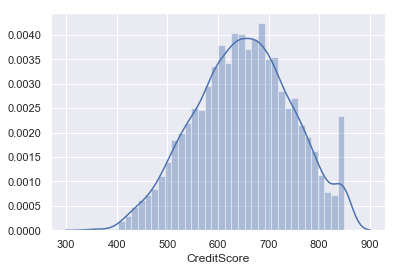

In [18]:
sns.distplot(df['CreditScore'])

The cutoff at 850 looks suspicious

Percentage of the customers with unusually high creditscore

In [19]:
100 * df[(df['CreditScore'] > 835)].shape[0] / df.shape[0]

3.1375

Looks ok to just get rid of them

In [20]:
df = df.loc[(df['CreditScore'] < 835), :]

## Categorical features

In [21]:
df.dtypes[df.dtypes == 'object']

Surname      object
Geography    object
Gender       object
dtype: object

### Surname

In [22]:
df = df.drop(['Surname'], axis=1)

### Geography

In [23]:
df['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [24]:
[print(c, df.loc[df['Geography'] == c, 'Exited'].mean())
 for c in df['Geography'].unique()]

France 0.16277278562259306
Spain 0.1660631143300569
Germany 0.3240837696335079


[None, None, None]

In [25]:
df['Geography'] = (df['Geography'] == 'Germany')

### Gender

In [26]:
[print(c,df.loc[df['Gender'] == c, 'Exited'].mean())
 for c in df['Gender'].unique()]

Female 0.24836971930819393
Male 0.16575635241035383


[None, None]

In [27]:
df['Gender'] = (df['Gender']=='Female')

In [28]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ZeroBalance
CustomerId,,,,,,,,,,,
15720050,727,False,True,28,2,False,1,0,101433.76,0,False
15696301,719,False,True,37,9,False,1,0,25803.59,1,False
15643865,601,False,True,40,3,False,0,1,164652.02,1,False
15677538,569,False,False,38,7,False,1,1,108469.20,0,True
15740494,633,False,True,33,3,True,1,0,191111.02,0,True


## Standardizing the data

In [33]:
norm_data = df.copy()
norm_data.loc[:, norm_data.columns != 'Exited'] = \
    pd.DataFrame(
    data=StandardScaler().fit_transform(norm_data.loc[:,
                                                      norm_data.columns !=
                                                      'Exited']),
    index=norm_data.index,
    columns=[c for c in norm_data.columns if c != 'Exited'])

In [34]:
norm_data.head()

,CreditScore,Geography,Gender,Age,Tenure,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ZeroBalance
CustomerId,,,,,,,,,,,
15720050,0.918502,-0.572476,1.092672,-1.038674,-1.046751,-0.919487,0.646526,-1.027783,0.017028,0,-0.754279
15696301,0.830470,-0.572476,1.092672,-0.179982,1.372531,-0.919487,0.646526,-1.027783,-1.307519,1,-0.754279
15643865,-0.467997,-0.572476,1.092672,0.106248,-0.701139,-0.919487,-1.546729,0.972968,1.124199,1,-0.754279
15677538,-0.820123,-0.572476,-0.915188,-0.084572,0.681308,-0.919487,0.646526,0.972968,0.140243,0,1.325769
15740494,-0.115870,-0.572476,1.092672,-0.561623,-0.701139,1.087563,0.646526,-1.027783,1.587588,0,1.325769


## Model

In [35]:
model = Logit(norm_data['Exited'],
              add_constant(norm_data.drop(['Exited'], axis=1))).fit()

Optimization terminated successfully.
         Current function value: 0.388962
         Iterations 7


In [36]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Exited   No. Observations:                 7738
Model:                          Logit   Df Residuals:                     7727
Method:                           MLE   Df Model:                           10
Date:                Wed, 29 Jan 2020   Pseudo R-squ.:                  0.2299
Time:                        16:57:44   Log-Likelihood:                -3009.8
converged:                       True   LL-Null:                       -3908.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.8513      0.040    -45.850      0.000      -1.930      -1.772
CreditScore        -0.0485      0.032     -1.496      0.135      -0.112       0.015
Geography           0.4454      0.034     13.207      0.000       0.379       0.511
Gender              0.2515      0.032      7.754      0.000       0.188       0.315
Age                 0.7741      0.032     23.863      0.000       0.711       0.838
Tenure             -0.0875      0.032     -2.709      0.007      -0.151      -0.024
NumOfProducts      -0.8922      0.040    -22.167      0.000      -0.971      -0.813
HasCrCard          -0.0523      0.032     -1.626      0.104      -0.115       0.011
IsActiveMember     -0.5309      0.034    -15.523      0.000      -0.598      -0.464
EstimatedSalary     0.0340      0.033      1.042      0.298      -0.030       0.098
ZeroBalance         0.1770      0.041      4.326      0.000       0.097       0.257
===================================================================================
"""

### Dropping low p-value features

In [37]:
features = [
    f 
    for f, p in zip([c for c in norm_data.columns
                     if c != 'Exited'], model.pvalues[1:])
    if p < 0.01
]

In [38]:
features

['Geography',
 'Gender',
 'Age',
 'Tenure',
 'NumOfProducts',
 'IsActiveMember',
 'ZeroBalance']

In [39]:
model = Logit(norm_data['Exited'],
              add_constant(norm_data.loc[:, features])).fit()

Optimization terminated successfully.
         Current function value: 0.389343
         Iterations 7


In [40]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Exited   No. Observations:                 7738
Model:                          Logit   Df Residuals:                     7730
Method:                           MLE   Df Model:                            7
Date:                Wed, 29 Jan 2020   Pseudo R-squ.:                  0.2292
Time:                        16:58:03   Log-Likelihood:                -3012.7
converged:                       True   LL-Null:                       -3908.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.8491      0.040    -45.858      0.000      -1.928      -1.770
Geography          0.4443      0.034     13.189      0.000       0.378       0.510
Gender             0.2515      0.032      7.761      0.000       0.188       0.315
Age                0.7739      0.032     23.876      0.000       0.710       0.837
Tenure            -0.0884      0.032     -2.740      0.006      -0.152      -0.025
NumOfProducts     -0.8918      0.040    -22.164      0.000      -0.971      -0.813
IsActiveMember    -0.5314      0.034    -15.557      0.000      -0.598      -0.464
ZeroBalance        0.1745      0.041      4.269      0.000       0.094       0.255
==================================================================================
"""

In [41]:
model.params.abs().sort_values(ascending=False)

const             1.849128
NumOfProducts     0.891847
Age               0.773895
IsActiveMember    0.531409
Geography         0.444259
Gender            0.251450
ZeroBalance       0.174484
Tenure            0.088439
dtype: float64

## VIF

In [43]:
selection_data = norm_data.loc[:, features].copy()
drop_cols = []

selected_features = selection_data.drop(drop_cols, axis=1)
vif_report = [
    (col, variance_inflation_factor(selected_features.values, i))
    for i, col in enumerate(selected_features.columns)
]
for col, vif in sorted(vif_report, key=lambda x: x[1], reverse=True):
    print(f'{col}: {vif}')

ZeroBalance: 1.4782915784650257
Geography: 1.2623003363470935
NumOfProducts: 1.217837241156703
Age: 1.023944648499914
IsActiveMember: 1.011266541117195
Gender: 1.0030849784891251
Tenure: 1.002351434539453


### Cross-validation for the initial data

In [44]:
score = cross_val_score(
    LogisticRegression(C=10e10),
    df.drop(drop_cols, axis=1),
    df['Exited'],
    scoring='roc_auc',
    cv=5
)

print(f'mean: {score.mean()}')
print(f'std: {score.std()}')

mean: 0.6890722996174783
std: 0.011436478582151837


### Cross-validation for modified data

In [45]:
score = cross_val_score(
    LogisticRegression(C=10e10),
    norm_data.loc[:,norm_data.columns!='Exited'],
    norm_data['Exited'],
    scoring='roc_auc',
    cv=5
)

print(f'mean: {score.mean()}')
print(f'std: {score.std()}')

mean: 0.8207212410712883
std: 0.009619339126700184


## Regularization

In [46]:
from sklearn.model_selection import GridSearchCV

In [47]:
X_train, X_test, y_train, y_test = \
    train_test_split(norm_data.loc[:, norm_data.columns != 'Exited'],
                     norm_data['Exited'], test_size=0.3)

In [48]:
params = {'C': np.logspace(-3, 3, 50),
          'penalty':['l2']}

best_logit = GridSearchCV(
    LogisticRegression(random_state=42), 
    params,
    verbose=True,
    n_jobs=-1,
    cv=5,
    scoring='roc_auc'
)

best_logit.fit(
    X_train, y_train
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed:    3.1s finished


GridSearchCV(cv=5, error_score='raise-deprecating',
             estimator=LogisticRegression(C=1.0, class_weight=None, dual=False,
                                          fit_intercept=True,
                                          intercept_scaling=1, l1_ratio=None,
                                          max_iter=100, multi_class='warn',
                                          n_jobs=None, penalty='l2',
                                          random_state=42, solver='warn',
                                          tol=0.0001, verbose=0,
                                          warm_start=False),
             iid='warn', n_jobs=-1,
             param_grid={'C': array([1.00000000e-0...
       8.28642773e+00, 1.09854114e+01, 1.45634848e+01, 1.93069773e+01,
       2.55954792e+01, 3.39322177e+01, 4.49843267e+01, 5.96362332e+01,
       7.90604321e+01, 1.04811313e+02, 1.38949549e+02, 1.84206997e+02,
       2.44205309e+02, 3.23745754e+02, 4.29193426e+02, 5.68986603e+02,
       7.

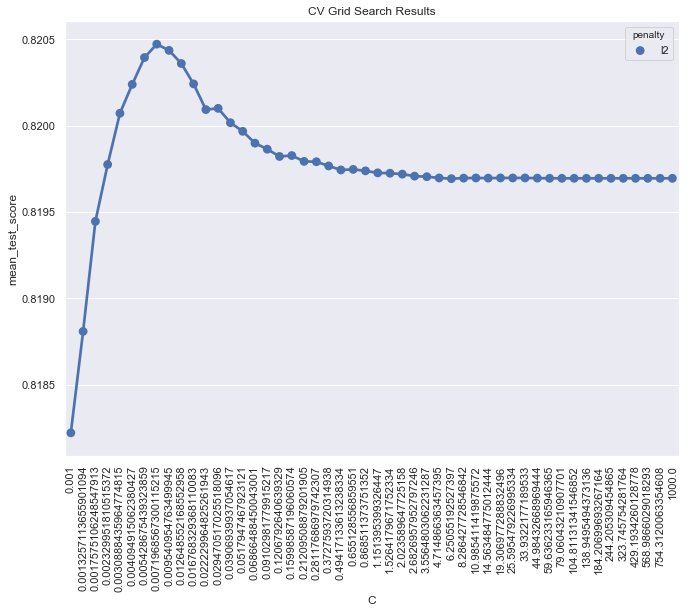

In [49]:
fig = plot_cv_results(best_logit.cv_results_, 'C', 'penalty')

In [51]:
roc_auc_score(y_test, best_logit.best_estimator_.decision_function(X_test))

0.8189507879064201

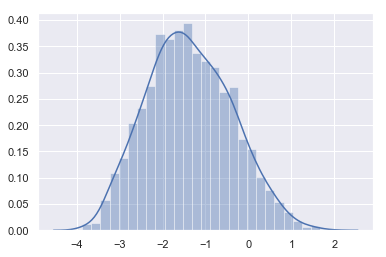

In [52]:
sns.distplot(best_logit.best_estimator_.decision_function(X_test))

## Results submission

In [58]:
def preprocess(data):
    df = data.copy()
    df['ZeroBalance'] = (df['Balance'] == 0)
    df = df.drop(['Balance'], axis=1)
    df['NumOfProducts'] = (df['NumOfProducts'] == 2)
    df = df.drop(['Surname'], axis=1)
    df['Geography'] = (df['Geography'] == 'Germany')
    df['Gender'] = (df['Gender'] == 'Female')
    norm_data = df.copy()
    norm_data.loc[:, (norm_data.columns != 'Exited') &
                  (norm_data.columns != 'CustomerId')] = \
        pd.DataFrame(data=StandardScaler().fit_transform(
            norm_data.loc[:, norm_data.columns != 'Exited']),
                     index=norm_data.index,
                     columns=[c for c in norm_data.columns
                              if c != 'Exited'])

    return norm_data

In [59]:
test_df = pd.read_csv('data/churn_test.csv')
test_proc = preprocess(test_df)
y_pred = best_logit.best_estimator_.decision_function(
    test_proc.loc[:, test_proc.columns != 'CustomerId'])
sub_df = pd.concat([test_proc['CustomerId'], 
                    pd.Series(y_pred)], axis=1,
                   ignore_index=True)

sub_df.columns = ['CustomerId','Exited']

In [60]:
sub_df = sub_df.set_index('CustomerId')

In [61]:
sub_df.to_csv('data/predicted.csv')